## Customer Segmentation Analysis using Deep Learning (Restricted Boltzmann Machine) on Online Retail Data

**Course: Artificial Neural Networks & Deep Learning**

**Assignment: CIA-2**

**Name: Varad Kulkarni**

**Class: TY-A-AIDS**

**Roll No.: A-56**



**Dataset: Online Retail II (UCI)**

# Customer Segmentation using Deep Learning (Boltzmann Machine)

## Objective
The objective of this project is to perform customer segmentation using a Restricted Boltzmann Machine (RBM) implemented in TensorFlow.

The model learns latent features from customer purchase behavior and groups customers based on similar shopping patterns.

Dataset: Online Retail II dataset from UCI Machine Learning Repository.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

## 1. Data Loading and Cleaning

Steps:
- Load dataset
- Remove missing values
- Remove negative quantities (returns)
- Remove duplicates

In [2]:
# Load dataset
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/ANNDL/ANNDL CIE TA/online_retail_II.xlsx", sheet_name="Year 2010-2011")

Due to the large size and sparsity of the dataset, sampling was applied to ensure efficient training of the RBM model without compromising pattern learning.

In [3]:
# Take random sample of 15,000 rows
df = df.sample(n=15000, random_state=42)
print("Sampled Shape:", df.shape)

Sampled Shape: (15000, 8)


In [16]:
# Remove customers with very few purchases
customer_counts = df['Customer ID'].value_counts()
valid_customers = customer_counts[customer_counts > 5].index
df = df[df['Customer ID'].isin(valid_customers)]

In [17]:
print(df.head())
print(df.info())

df = df.dropna()

df = df[df['Quantity'] > 0]

df = df.drop_duplicates()

print("Cleaned Shape:", df.shape)

       Invoice StockCode                         Description  Quantity  \
209270  555199    85123A  WHITE HANGING HEART T-LIGHT HOLDER         1   
525711  580635     21519     GIN & TONIC DIET GREETING CARD         12   
111488  545721     82484   WOOD BLACK BOARD ANT WHITE FINISH         1   
499265  578664     22065      CHRISTMAS PUDDING TRINKET POT          2   
320907  565118     22662         LUNCH BAG DOLLY GIRL DESIGN         2   

               InvoiceDate  Price  Customer ID         Country  
209270 2011-06-01 12:05:00   2.95      14606.0  United Kingdom  
525711 2011-12-05 12:30:00   0.42      14649.0  United Kingdom  
111488 2011-03-07 10:52:00   7.90      15039.0  United Kingdom  
499265 2011-11-24 16:59:00   0.39      15910.0  United Kingdom  
320907 2011-09-01 11:33:00   1.65      15039.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
Index: 6029 entries, 209270 to 377648
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ---

In [18]:
print(f"Size of data is :{df.size}")
print(f"Shape of data is :{df.shape}")

Size of data is :48232
Shape of data is :(6029, 8)


##2. Exploratory Data Analysis

We analyze:
- Top products
- Purchase patterns

In [19]:
sns.set_style('darkgrid')

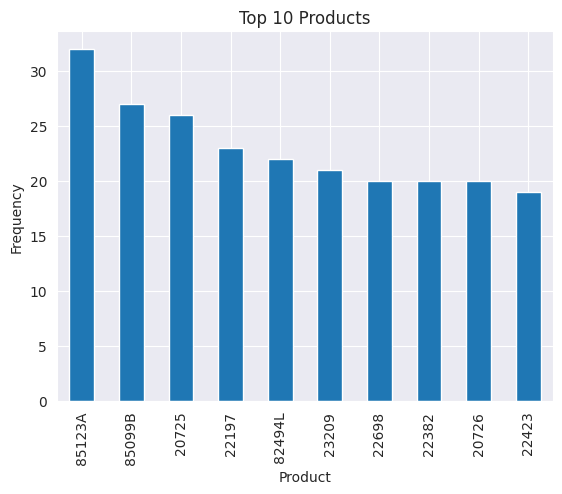

In [20]:
top_products = df['StockCode'].value_counts().head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Frequency")
plt.show()

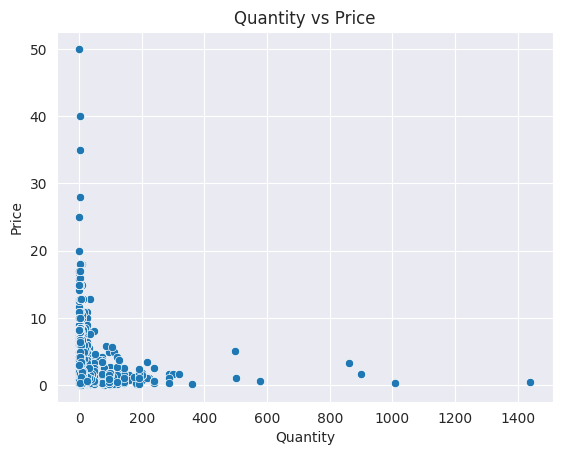

In [21]:
sns.scatterplot(data=df, x='Quantity', y='Price')
plt.title("Quantity vs Price")
plt.show()

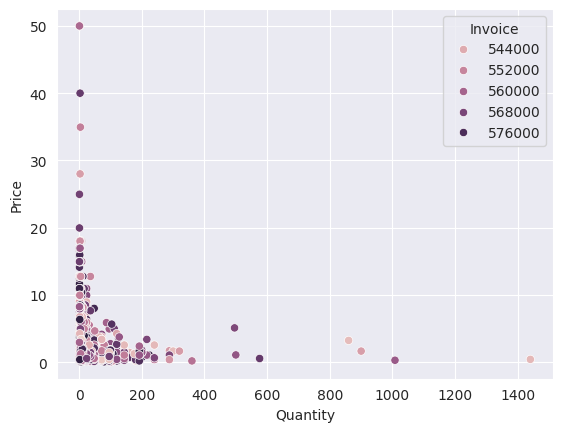

In [22]:
sns.scatterplot(data=df, x='Quantity', y='Price', hue='Invoice')
plt.show()

### Distribution of Price and Quantity

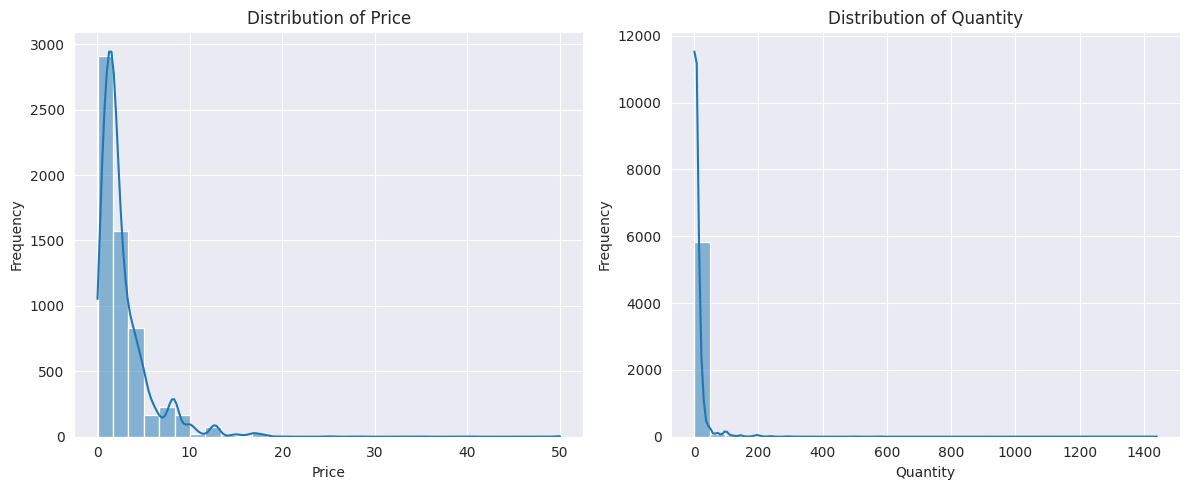

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Sales by Country

/tmp/ipykernel_15325/814313935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.index, y=country_sales.values, palette='viridis')


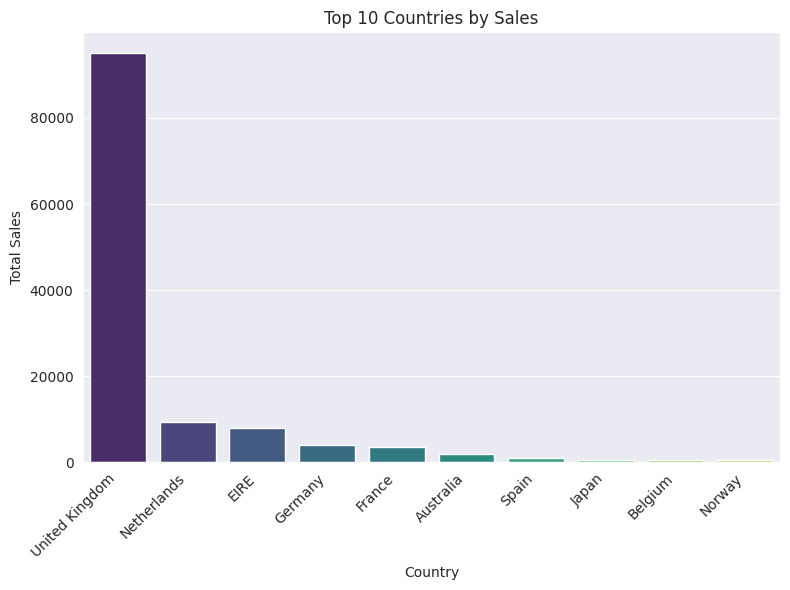

In [25]:
df['Sales'] = df['Quantity'] * df['Price']
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=country_sales.index, y=country_sales.values, palette='viridis')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

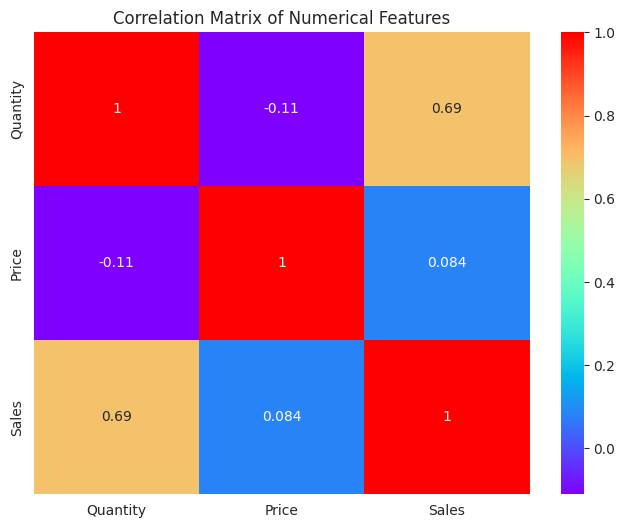

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Quantity', 'Price', 'Sales']].corr(), annot=True, cmap='rainbow')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 3. Data Preprocessing

- Select relevant features
- Normalize numerical values

In [32]:
df = df[['Customer ID', 'StockCode', 'Quantity']]

# Normalize quantity manually (0–1)
df['Quantity'] = (df['Quantity'] - df['Quantity'].min()) / (df['Quantity'].max() - df['Quantity'].min())

df.head()

/tmp/ipykernel_15325/1750957245.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = (df['Quantity'] - df['Quantity'].min()) / (df['Quantity'].max() - df['Quantity'].min())


,Customer ID,StockCode,Quantity
209270,14606.0,85123A,0.000000
525711,14649.0,21519,0.007644
111488,15039.0,82484,0.000000
499265,15910.0,22065,0.000695
320907,15039.0,22662,0.000695


## 4. Data Transformation

Convert data into binary matrix:
- Rows → Customers
- Columns → Products
- 1 = Purchased, 0 = Not purchased

In [33]:
customer_product = df.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum'
)

customer_product = customer_product.fillna(0)

# Convert to binary
customer_product[customer_product > 0] = 1

data = customer_product.values.astype(np.float32)

print("Matrix Shape:", data.shape)

Matrix Shape: (490, 1860)


## 5. Training Restricted Boltzmann Machine (TensorFlow)

We implement RBM using TensorFlow with:
- Visible layer = Products
- Hidden layer = Latent features
- Contrastive Divergence for training

In [40]:
class RBM(tf.Module):
    def __init__(self, n_visible, n_hidden):
        self.W = tf.Variable(tf.random.normal([n_visible, n_hidden], stddev=0.01))
        self.h_bias = tf.Variable(tf.zeros([n_hidden]))
        self.v_bias = tf.Variable(tf.zeros([n_visible]))

    def sample_h(self, v):
        prob_h = tf.nn.sigmoid(tf.matmul(v, self.W) + self.h_bias)
        return prob_h, tf.nn.relu(tf.sign(prob_h - tf.random.uniform(tf.shape(prob_h))))

    def sample_v(self, h):
        prob_v = tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.v_bias)
        return prob_v, tf.nn.relu(tf.sign(prob_v - tf.random.uniform(tf.shape(prob_v))))

    def reconstruct(self, v):
        h_prob = tf.nn.sigmoid(tf.matmul(v, self.W) + self.h_bias)
        v_reconstructed = tf.nn.sigmoid(tf.matmul(h_prob, tf.transpose(self.W)) + self.v_bias)
        return v_reconstructed

    def reconstruction_error(self, data):
        v = tf.convert_to_tensor(data, dtype=tf.float32) # Ensure data type is float32
        v_recon = self.reconstruct(v)
        error = tf.reduce_mean(tf.square(v - v_recon))
        return error.numpy()

    def train(self, data, epochs=5, batch_size=64, lr=0.01):
        n_samples = data.shape[0]

        for epoch in range(epochs):
            for i in range(0, n_samples, batch_size):
                v0 = data[i:i+batch_size]

                # Positive phase
                h0_prob, h0 = self.sample_h(v0)

                # Negative phase
                v1_prob, v1 = self.sample_v(h0)
                h1_prob, _ = self.sample_h(v1)

                # Update weights
                self.W.assign_add(lr * (tf.matmul(tf.transpose(v0), h0_prob) -
                                        tf.matmul(tf.transpose(v1), h1_prob)) / batch_size)

                self.v_bias.assign_add(lr * tf.reduce_mean(v0 - v1, axis=0))
                self.h_bias.assign_add(lr * tf.reduce_mean(h0_prob - h1_prob, axis=0))

            print(f"Epoch {epoch+1} completed")

Train Model


In [41]:
n_visible = data.shape[1]
n_hidden = 50

rbm = RBM(n_visible, n_hidden)
rbm.train(data, epochs=5)

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


## 6. Model Evaluation

Since Restricted Boltzmann Machines are unsupervised models, traditional accuracy metrics are not applicable.

Instead, we evaluate the model using:
- Reconstruction Error
- Train vs Test comparison

Reconstruction error measures how well the model can reconstruct the original input data after encoding and decoding.

In [42]:
# Train-Test Split (80-20)
split = int(0.8 * data.shape[0])

train_data = data[:split]
test_data = data[split:]

print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

Train Shape: (392, 1860)
Test Shape: (98, 1860)


In [44]:
train_error = rbm.reconstruction_error(train_data)
test_error = rbm.reconstruction_error(test_data)

print("Train Reconstruction Error:", train_error)
print("Test Reconstruction Error:", test_error)

Train Reconstruction Error: 0.17527533
Test Reconstruction Error: 0.1752441


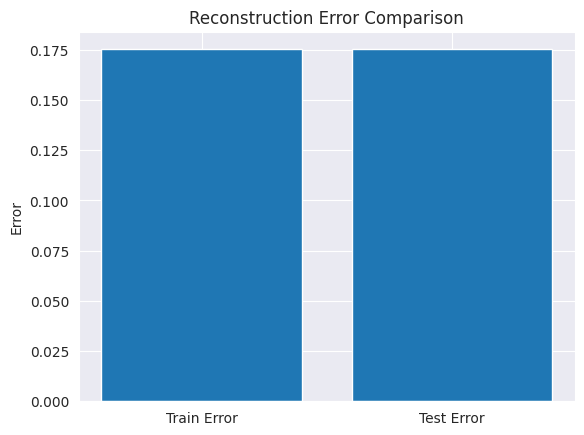

In [45]:
labels = ['Train Error', 'Test Error']
values = [train_error, test_error]

plt.figure()
plt.bar(labels, values)
plt.title("Reconstruction Error Comparison")
plt.ylabel("Error")
plt.show()

## Evaluation Results

The reconstruction error obtained for the RBM model is:

- Train Error: 0.1753
- Test Error: 0.1752

### Observations:
- The training and testing errors are almost identical, indicating that the model does not suffer from overfitting.
- The low reconstruction error shows that the model has successfully learned the underlying patterns in customer purchasing behavior.
- The RBM is able to generalize well to unseen data.

### Conclusion:
The model effectively captures customer-product relationships and can be used for customer segmentation and recommendation tasks.